In [2]:
import torch, random
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## Passo 1: Carregar o Dataset (SVHN)
Primeiro, precisamos carregar o SVHN. Ele tem 3 canais (RGB), então vamos normalizá-lo adequadamente.

In [3]:
# --- 1. Definir Transformações ---
# SVHN é 3x32x32
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# --- 2. Baixar os datasets ---
# split='train' e split='test'
train_data = datasets.SVHN(
    root="data",
    split='train',
    download=True,
    transform=transform
)

val_data = datasets.SVHN(
    root="data",
    split='test',
    download=True,
    transform=transform
)

# --- 3. Criar os DataLoaders ---
# A classe Architecture espera por train_loader e val_loader
train_loader = DataLoader(
    dataset=train_data,
    batch_size=64, # Pode ajustar
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_data,
    batch_size=64,
    shuffle=False
)

print(f"Imagens de treino: {len(train_data)}")
print(f"Imagens de validação: {len(val_data)}")

100%|██████████| 182M/182M [00:03<00:00, 45.8MB/s] 
100%|██████████| 64.3M/64.3M [00:02<00:00, 27.9MB/s]


Imagens de treino: 73257
Imagens de validação: 26032


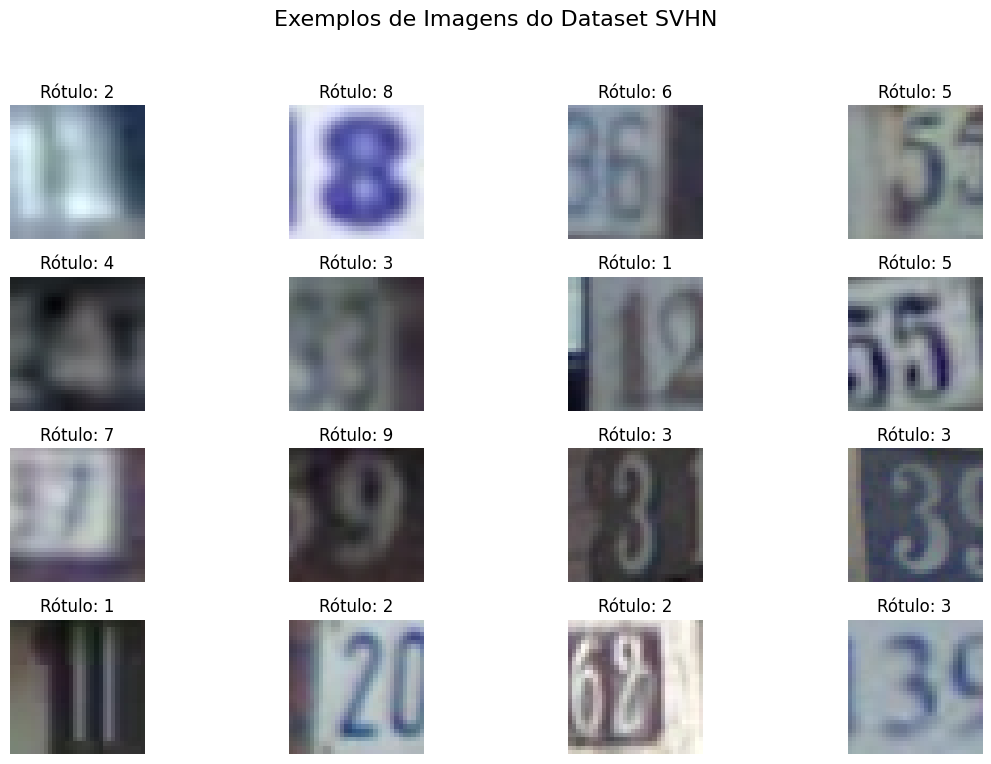

In [ ]:
# --- 1. Pegar um lote de imagens ---
# O train_loader já foi definido na célula anterior
try:
    images, labels = next(iter(train_loader))
except Exception as e:
    print(f"Erro ao carregar o lote: {e}")
    print("Certifique-se de que a célula anterior foi executada corretamente.")

# --- 2. Criar a figura para o plot ---
# Vamos plotar as 16 primeiras imagens do lote
plt.figure(figsize=(12, 8))
plt.suptitle("Exemplos de Imagens do Dataset SVHN", fontsize=16)

for i in range(16):
    # Criar o subplot
    ax = plt.subplot(4, 4, i + 1)

    # Pegar a imagem i e seu rótulo
    image = images[i]
    label = labels[i].item()

    # --- 3. Des-normalizar e formatar a imagem ---
    # O transform original usou mean=0.5, std=0.5
    # Necessário reverter isso para o plot (img = img * std + mean)
    image = image * 0.5 + 0.5

    # Matplotlib espera (Altura, Largura, Canais)
    # PyTorch dá (Canais, Altura, Largura)
    # Então, precisamos permutar as dimensões
    image_to_plot = image.permute(1, 2, 0)

    ax.imshow(image_to_plot)
    ax.set_title(f"Rótulo: {label}")
    ax.axis("off") # Remover os eixos

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para o supertítulo
plt.show()

## Passo 2: Adaptar a Classe Architecture (para Acurácia)

1. No __init__: Adicione train_accs e val_accs para guardar os valores.
2. No _make_train_step_fn: Faça a função calcular e retornar a acurácia.
3. No _make_val_step_fn: Faça o mesmo para a validação.
4. No _mini_batch: Faça ele processar a acurácia também.
5. No train: Armazene os valores de acurácia.
6. No plot_losses: Faça ele plotar a acurácia também.

In [8]:
class Architecture(object):
    def __init__(self, model, loss_fn, optimizer):
        # Here we define the attributes of our class

        # We start by storing the arguments as attributes
        # to use them later
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # Let's send the model to the specified device right away
        self.model.to(self.device)

        # These attributes are defined here, but since they are
        # not informed at the moment of creation, we keep them None
        self.train_loader = None
        self.val_loader = None

        # These attributes are going to be computed internally
        self.losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.total_epochs = 0

        # Creates the train_step function for our model,
        # loss function and optimizer
        # Note: there are NO ARGS there! It makes use of the class
        # attributes directly
        self.train_step_fn = self._make_train_step_fn()
        # Creates the val_step function for our model and loss
        self.val_step_fn = self._make_val_step_fn()

        # for hook purposes
        self.handles = {}
        self.visualization = {}

    def to(self, device):
        # This method allows the user to specify a different device
        # It sets the corresponding attribute (to be used later in
        # the mini-batches) and sends the model to the device
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"Couldn't send it to {device}, sending it to {self.device} instead.")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        # This method allows the user to define which train_loader (and val_loader, optionally) to use
        # Both loaders are then assigned to attributes of the class
        # So they can be referred to later
        self.train_loader = train_loader
        self.val_loader = val_loader

    def _make_train_step_fn(self):
        # This method does not need ARGS... it can refer to
        # the attributes: self.model, self.loss_fn and self.optimizer

        # Builds function that performs a step in the train loop
        def perform_train_step_fn(x, y):
            # Sets model to TRAIN mode
            self.model.train()

            # Step 1 - Computes our model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # Step 3 - Computes gradients for both "a" and "b" parameters
            loss.backward()
            # Step 4 - Updates parameters using gradients and the learning rate
            self.optimizer.step()
            self.optimizer.zero_grad()
            # Step 5 - Accuracy
            preds = torch.argmax(yhat, dim=1)
            acc = (preds == y).sum().item() / len(y)

            # Returns the loss
            return loss.item(), acc

        # Returns the function that will be called inside the train loop
        return perform_train_step_fn

    def _make_val_step_fn(self):
        # Builds function that performs a step in the validation loop
        def perform_val_step_fn(x, y):
            # Sets model to EVAL mode
            self.model.eval()

            # Step 1 - Computes our model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # There is no need to compute Steps 3 and 4, since we don't update parameters during evaluation
            # Step 5 - Accuracy
            preds = torch.argmax(yhat, dim=1)
            acc = (preds == y).sum().item() / len(y)

            return loss.item(), acc

        return perform_val_step_fn

    def _mini_batch(self, validation=False):
        # The mini-batch can be used with both loaders
        # The argument `validation`defines which loader and
        # corresponding step function is going to be used
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn

        if data_loader is None:
            return None

        # Once the data loader and step function, this is the same
        # mini-batch loop we had before
        mini_batch_losses = []
        mini_batch_accs = []

        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss, mini_batch_acc = step_fn(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)
            mini_batch_accs.append(mini_batch_acc)

        loss = np.mean(mini_batch_losses)
        acc = np.mean(mini_batch_accs)
        return loss, acc

    # this function was updated in this class
    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        try:
            self.train_loader.sampler.generator.manual_seed(seed)
        except AttributeError:
            pass

    def train(self, n_epochs, seed=42):
        # To ensure reproducibility of the training process
        self.set_seed(seed)

        for epoch in range(n_epochs):
            # Keeps track of the numbers of epochs
            # by updating the corresponding attribute
            self.total_epochs += 1

            # inner loop
            # Performs training using mini-batches
            loss, acc = self._mini_batch(validation=False)
            self.losses.append(loss)
            self.train_accs.append(acc)

            # VALIDATION
            # no gradients in validation!
            with torch.no_grad():
                # Performs evaluation using mini-batches
                val_loss, val_acc = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)
                self.val_accs.append(val_acc)

            # Progress
            print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {loss:.4f} | Train Acc: {acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    def save_checkpoint(self, filename):
        # Builds dictionary with all elements for resuming training
        checkpoint = {'epoch': self.total_epochs,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict(),
                      'loss': self.losses,
                      'val_loss': self.val_losses}

        torch.save(checkpoint, filename)

    def load_checkpoint(self, filename):
        # Loads dictionary
        checkpoint = torch.load(filename)

        # Restore state for model and optimizer
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']

        self.model.train() # always use TRAIN for resuming training

    def predict(self, x):
        # Set is to evaluation mode for predictions
        self.model.eval()
        # Takes aNumpy input and make it a float tensor
        x_tensor = torch.as_tensor(x).float()
        # Send input to device and uses model for prediction
        y_hat_tensor = self.model(x_tensor.to(self.device))
        # Set it back to train mode
        self.model.train()
        # Detaches it, brings it to CPU and back to Numpy
        return y_hat_tensor.detach().cpu().numpy()

    def count_parameters(self):
      return sum(p.numel() for p in self.model.parameters() if p.requires_grad)

    def plot_losses(self):
        # MODIFICADO PARA PLOTAR LOSS E ACCURACY
        fig, axs = plt.subplots(1, 2, figsize=(15, 5))

        # Plot de Loss
        axs[0].plot(self.losses, label='Training Loss', c='b')
        axs[0].plot(self.val_losses, label='Validation Loss', c='r')
        axs[0].set_yscale('log')
        axs[0].set_xlabel('Epochs')
        axs[0].set_ylabel('Loss')
        axs[0].set_title('Training vs Validation Loss')
        axs[0].legend()

        # Plot de Accuracy
        axs[1].plot(self.train_accs, label='Training Accuracy', c='b')
        axs[1].plot(self.val_accs, label='Validation Accuracy', c='r')
        axs[1].set_xlabel('Epochs')
        axs[1].set_ylabel('Accuracy')
        axs[1].set_title('Training vs Validation Accuracy')
        axs[1].legend()

        plt.tight_layout()
        return fig

    @staticmethod
    def _visualize_tensors(axs, x, y=None, yhat=None, layer_name='', title=None):
        # The number of images is the number of subplots in a row
        n_images = len(axs)
        # Gets max and min values for scaling the grayscale
        minv, maxv = np.min(x[:n_images]), np.max(x[:n_images])
        # For each image
        for j, image in enumerate(x[:n_images]):
            ax = axs[j]
            # Sets title, labels, and removes ticks
            if title is not None:
                ax.set_title(f'{title} #{j}', fontsize=12)
            shp = np.atleast_2d(image).shape
            ax.set_ylabel(
                f'{layer_name}\n{shp[0]}x{shp[1]}',
                rotation=0, labelpad=40
            )
            xlabel1 = '' if y is None else f'\nLabel: {y[j]}'
            xlabel2 = '' if yhat is None else f'\nPredicted: {yhat[j]}'
            xlabel = f'{xlabel1}{xlabel2}'
            if len(xlabel):
                ax.set_xlabel(xlabel, fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])

            # Plots weight as an image
            ax.imshow(
                np.atleast_2d(image.squeeze()),
                cmap='gray',
                vmin=minv,
                vmax=maxv
            )
        return

    def visualize_filters(self, layer_name, **kwargs):
        try:
            # Gets the layer object from the model
            layer = self.model
            for name in layer_name.split('.'):
                layer = getattr(layer, name)
            # We are only looking at filters for 2D convolutions
            if isinstance(layer, nn.Conv2d):
                # Takes the weight information
                weights = layer.weight.data.cpu().numpy()
                # weights -> (channels_out (filter), channels_in, H, W)
                n_filters, n_channels, _, _ = weights.shape

                # Builds a figure
                size = (2 * n_channels + 2, 2 * n_filters)
                fig, axes = plt.subplots(n_filters, n_channels,
                                        figsize=size)
                axes = np.atleast_2d(axes)
                axes = axes.reshape(n_filters, n_channels)
                # For each channel_out (filter)
                for i in range(n_filters):
                    Architecture._visualize_tensors(
                        axes[i, :],
                        weights[i],
                        layer_name=f'Filter #{i}',
                        title='Channel'
                    )

                for ax in axes.flat:
                    ax.label_outer()

                fig.tight_layout()
                return fig
        except AttributeError:
            return

    def attach_hooks(self, layers_to_hook, hook_fn=None):
        # Clear any previous values
        self.visualization = {}
        # Creates the dictionary to map layer objects to their names
        modules = list(self.model.named_modules())
        layer_names = {layer: name for name, layer in modules[1:]}

        if hook_fn is None:
            # Hook function to be attached to the forward pass
            def hook_fn(layer, inputs, outputs):
                # Gets the layer name
                name = layer_names[layer]
                # Detaches outputs
                values = outputs.detach().cpu().numpy()
                # Since the hook function may be called multiple times
                # for example, if we make predictions for multiple mini-batches
                # it concatenates the results
                if self.visualization[name] is None:
                    self.visualization[name] = values
                else:
                    self.visualization[name] = np.concatenate([self.visualization[name], values])

        for name, layer in modules:
            # If the layer is in our list
            if name in layers_to_hook:
                # Initializes the corresponding key in the dictionary
                self.visualization[name] = None
                # Register the forward hook and keep the handle in another dict
                self.handles[name] = layer.register_forward_hook(hook_fn)

    def remove_hooks(self):
        # Loops through all hooks and removes them
        for handle in self.handles.values():
            handle.remove()
        # Clear the dict, as all hooks have been removed
        self.handles = {}

    def visualize_outputs(self, layers, n_images=10, y=None, yhat=None):
        layers = filter(lambda l: l in self.visualization.keys(), layers)
        layers = list(layers)
        shapes = [self.visualization[layer].shape for layer in layers]
        n_rows = [shape[1] if len(shape) == 4 else 1
                  for shape in shapes]
        total_rows = np.sum(n_rows)

        fig, axes = plt.subplots(total_rows, n_images,
                                figsize=(1.5*n_images, 1.5*total_rows))
        axes = np.atleast_2d(axes).reshape(total_rows, n_images)

        # Loops through the layers, one layer per row of subplots
        row = 0
        for i, layer in enumerate(layers):
            start_row = row
            # Takes the produced feature maps for that layer
            output = self.visualization[layer]

            is_vector = len(output.shape) == 2

            for j in range(n_rows[i]):
                Architecture._visualize_tensors(
                    axes[row, :],
                    output if is_vector else output[:, j].squeeze(),
                    y,
                    yhat,
                    layer_name=layers[i] \
                              if is_vector \
                              else f'{layers[i]}\nfil#{row-start_row}',
                    title='Image' if (row == 0) else None
                )
                row += 1

        for ax in axes.flat:
            ax.label_outer()

        plt.tight_layout()
        return fig

    def correct(self, x, y, threshold=.5):
        self.model.eval()
        yhat = self.model(x.to(self.device))
        y = y.to(self.device)
        self.model.train()

        # We get the size of the batch and the number of classes
        # (only 1, if it is binary)
        n_samples, n_dims = yhat.shape
        if n_dims > 1:
            # In a multiclass classification, the biggest logit
            # always wins, so we don't bother getting probabilities

            # This is PyTorch's version of argmax,
            # but it returns a tuple: (max value, index of max value)
            _, predicted = torch.max(yhat, 1)
        else:
            n_dims += 1
            # In binary classification, we NEED to check if the
            # last layer is a sigmoid (and then it produces probs)
            if isinstance(self.model, nn.Sequential) and \
              isinstance(self.model[-1], nn.Sigmoid):
                predicted = (yhat > threshold).long()
            # or something else (logits), which we need to convert
            # using a sigmoid
            else:
                predicted = (F.sigmoid(yhat) > threshold).long()

        # How many samples got classified correctly for each class
        result = []
        for c in range(n_dims):
            n_class = (y == c).sum().item()
            n_correct = (predicted[y == c] == c).sum().item()
            result.append((n_correct, n_class))
        return torch.tensor(result)


    @staticmethod
    def loader_apply(loader, func, reduce='sum'):
        results = [func(x, y) for i, (x, y) in enumerate(loader)]
        results = torch.stack(results, axis=0)

        if reduce == 'sum':
            results = results.sum(axis=0)
        elif reduce == 'mean':
            results = results.float().mean(axis=0)

        return results

## Passo 3: Definir o Modelo LeNet-like (para SVHN 3x32x32)
O lenet no notebook de exemplo foi feito para MNIST (1x28x28). Vamos adaptar para SVHN (3x32x32).

- Adaptação 1: in_channels da primeira Conv2d será 3.

- Adaptação 2: O tamanho de entrada do Flatten vai mudar.

Vamos traçar as dimensões (Input: 3x32x32):

Fórmula:
$$
Output = \frac{Input - Kernel + 2 \times Padding}{Stride} + 1
$$

1. C1: Conv2d(3, 6, 5, padding=2) -> (32+4-5)/1 + 1 = 32. Saída: 6x32x32

2. S2: MaxPool2d(2) -> 32/2 = 16. Saída: 6x16x16

3. C3: Conv2d(6, 16, 5, padding=0) -> (16+0-5)/1 + 1 = 12. Saída: 16x12x12

4. S4: MaxPool2d(2) -> 12/2 = 6. Saída: 16x6x6

5. C5: Conv2d(16, 120, 5, padding=0) -> (6+0-5)/1 + 1 = 2. Saída: 120x2x2

6. Flatten: 120 * 2 * 2 = 480 features

7. F6: Linear(480, 84)

8. OUTPUT: Linear(84, 10) (SVHN tem 10 classes, 0-9)

In [9]:
torch.manual_seed(42)

# --- 4. Definir a Arquitetura ---
# Usamos os mesmos nomes do exemplo (C1, S2, etc.)
# para que os hooks funcionem.

model_svhn = nn.Sequential()

# Bloco 1: 3@32x32 -> 6@32x32 -> 6@16x16
model_svhn.add_module('C1', nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2))
model_svhn.add_module('Relu1', nn.ReLU())
model_svhn.add_module('S2', nn.MaxPool2d(kernel_size=2))

# Bloco 2: 6@16x16 -> 16@12x12 -> 16@6x6
model_svhn.add_module('C3', nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5))
model_svhn.add_module('Relu2', nn.ReLU())
model_svhn.add_module('S4', nn.MaxPool2d(kernel_size=2))

# Bloco 3: 16@6x6 -> 120@2x2
model_svhn.add_module('C5', nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5))
model_svhn.add_module('Relu3', nn.ReLU())

# Flattening
model_svhn.add_module('Flatten', nn.Flatten())

# Classificador
# A entrada F6 precisa ser 120*2*2 = 480
model_svhn.add_module('F6', nn.Linear(in_features=120*2*2, out_features=84))
model_svhn.add_module('Relu4', nn.ReLU())
model_svhn.add_module('OUTPUT', nn.Linear(in_features=84, out_features=10))

## Passo 4: Treinar o Modelo
Agora é só juntar tudo e rodar o treino.

Iniciando o treinamento...
Epoch 1/20 | Train Loss: 2.2502 | Train Acc: 18.14% | Val Loss: 2.2212 | Val Acc: 19.59%
Epoch 2/20 | Train Loss: 2.2302 | Train Acc: 18.92% | Val Loss: 2.2066 | Val Acc: 19.59%
Epoch 3/20 | Train Loss: 2.1307 | Train Acc: 23.02% | Val Loss: 1.9432 | Val Acc: 34.64%
Epoch 4/20 | Train Loss: 1.3873 | Train Acc: 55.24% | Val Loss: 0.8933 | Val Acc: 74.63%
Epoch 5/20 | Train Loss: 0.7503 | Train Acc: 77.73% | Val Loss: 0.6780 | Val Acc: 80.57%
Epoch 6/20 | Train Loss: 0.5892 | Train Acc: 83.07% | Val Loss: 0.5930 | Val Acc: 83.59%
Epoch 7/20 | Train Loss: 0.5154 | Train Acc: 85.20% | Val Loss: 0.5417 | Val Acc: 84.66%
Epoch 8/20 | Train Loss: 0.4675 | Train Acc: 86.47% | Val Loss: 0.5357 | Val Acc: 85.04%
Epoch 9/20 | Train Loss: 0.4311 | Train Acc: 87.49% | Val Loss: 0.4856 | Val Acc: 86.44%
Epoch 10/20 | Train Loss: 0.4008 | Train Acc: 88.35% | Val Loss: 0.4622 | Val Acc: 86.91%
Epoch 11/20 | Train Loss: 0.3770 | Train Acc: 89.12% | Val Loss: 0.4455 | Val Acc:

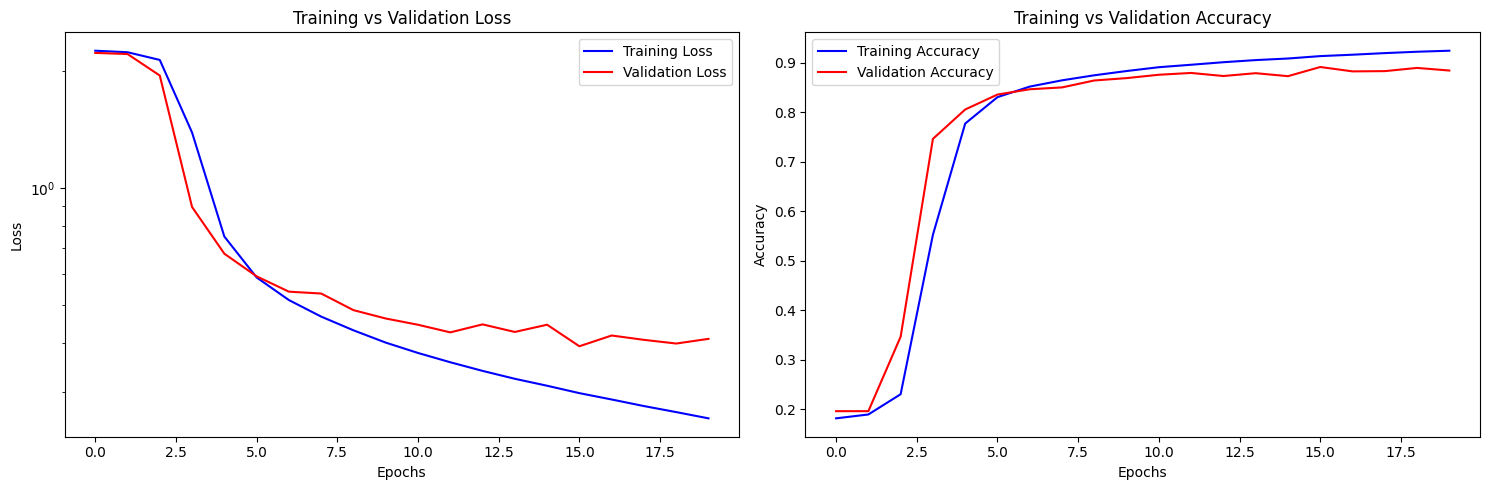

In [10]:
# --- 5. Configurar Treino ---
lr = 0.01 # Learning rate
epochs = 20 # Número de épocas

# SVHN é um problema de classificação multiclasse
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_svhn.parameters(), lr=lr)

# Instanciar a classe Architecture (com as modificações de acurácia)
arch = Architecture(model_svhn, loss_fn, optimizer)
arch.set_loaders(train_loader, val_loader)

# --- 6. Treinar ---
print("Iniciando o treinamento...")
arch.train(n_epochs=epochs)
print("Treinamento concluído!")

# --- 7. Registrar Métricas (Gráfico) ---
# (Item 3 do checklist)
fig = arch.plot_losses()
# fig.savefig("metricas_treino_val.png") # Para seu repositório

## Passo 5: Visualizar Ativações (Feature Maps)
Esta parte o seu professor já deixou pronta! Só precisamos chamar os métodos attach_hooks e visualize_outputs.

Visualizando Filtros de 'C1':

Visualizando Feature Maps (Ativações):


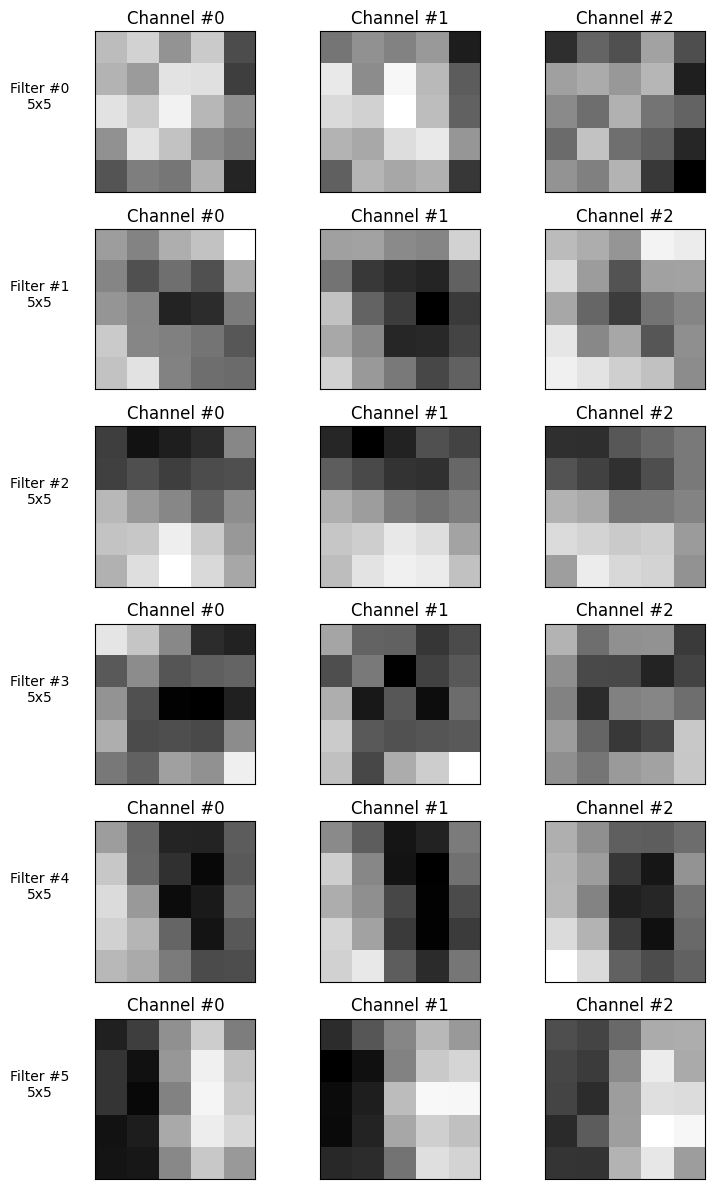

In [11]:
# --- 8. Implementar Hooks e Visualizar (Itens 4 e 6) ---

# Nomes das camadas que definimos no nn.Sequential
# Vamos visualizar todas, como pedido
layers_to_hook = ['C1', 'Relu1', 'S2', 'C3', 'Relu2', 'S4',
                  'C5', 'Relu3', 'Flatten', 'F6', 'Relu4', 'OUTPUT']

# 1. Anexar os hooks
arch.attach_hooks(layers_to_hook=layers_to_hook)

# 2. Pegar um lote de dados de validação
images_batch, labels_batch = next(iter(val_loader))

# 3. Fazer uma "previsão" para capturar as ativações
# O método .predict() da classe vai rodar o forward pass
# e o hook vai salvar as saídas em arch.visualization
logits = arch.predict(images_batch)
predicted = np.argmax(logits, 1)

# 4. Remover os hooks (boa prática)
arch.remove_hooks()

# --- 9. Visualizar os Filtros da primeira camada ---
print("Visualizando Filtros de 'C1':")
# (Bônus, mas muito bom para a análise)
fig_filters = arch.visualize_filters('C1')
# fig_filters.savefig("filtros_c1.png")

# --- 10. Visualizar os Feature Maps de todas as camadas ---
print("\nVisualizando Feature Maps (Ativações):")
# (Item 6 do checklist)
# Pegamos as 10 primeiras imagens do lote
fig_maps = arch.visualize_outputs(
    layers_to_hook,
    n_images=10,
    y=labels_batch,
    yhat=predicted
)
# fig_maps.savefig("feature_maps.png")